<a name="top"></a>
<br />

# <center> ALPS </center>

<font size="4"><br />This Jupyter Notebook provides the code for the following (Approximation by Localized Penalized Splines) ALPS framework functionalities:<br /><br />

1. [Using GCV to fit the ALPS model<br /><br />](#section_1)
1. [Using REML to fit the ALPS model<br /><br />](#section_2)
1. [Outlier detection in time series using two stage strategy<br /><br />](#section_3)
1. [Segregation of low frequency and high frequency effects<br /><br />](#section_4)
1. [Computation of first derivative for the produced approximation](#section_5)
</font>

### Select Kernel Restart & Run All to initialize the notebook

### Click the Hide / Show Code Cells button to hide / show the code cells<br />

In [1]:
import hublib.ui
hideCodeButton = hublib.ui.HideCodeButton(style = 'success')
#help (hideCodeButton)
display (hideCodeButton)

<IPython.core.display.Javascript object>

Button(button_style='success', description='Hide Code Cells', style=ButtonStyle())

In [2]:
# Importing the libraries

import sys
#print (sys.path)
import os

# Notes for running Jupyter on Debian 10:
# See: https://github.com/scipy/scipy/issues/11403
#import scipy
#print (scipy.__version__) # Jupyter Notebook: 1.3.0, Jupyter on Debian 10: 1.5.2, geospatial-plus python3 Kernel: 1.7.1
# Workaround:
#sys.path.insert (0,'/apps/share64/debian10/anaconda/anaconda-6/envs/volcashexpwf_anaconda_6/lib/python3.7/site-packages')
#print (scipy.__version__) # 1.3.1
# Note: For running Jupyter on Debian 10, also need to open a ticket to enable the tool to run in AppMode. Also see ./middleware/invoke.
# Note: The previous two cells can get removed when running Jupyter on Debian 10

import pickle
from matplotlib.pyplot import *
from IPython.display import HTML
import ipywidgets as widgets

# Setup paths to the bin and data directories
scriptpath = os.path.realpath(" ")
self_tooldir = os.path.dirname(scriptpath)
self_bindir = os.path.join(self_tooldir, "bin")
sys.path.insert (1, self_bindir)
self_datadir = os.path.join(self_tooldir, "data")

from Functions import *

# Getting the data

Data1 = pickle.load( open( os.path.join(self_datadir, "ts1.p"), "rb" ) )
Data2 = pickle.load( open( os.path.join(self_datadir, "ts2.p"), "rb" ) )
Data3 = pickle.load( open( os.path.join(self_datadir, "ts3.p"), "rb" ) )
Data4 = pickle.load( open( os.path.join(self_datadir, "ts4.p"), "rb" ) )


In [3]:
#prints Functions.py to the functions_ouput window
functions_output = widgets.Output()
functions_file = os.path.join(self_bindir, "Functions.py")
def show_functions(change):
    
    if showmore_button.description == 'Show Functions.py':
        
        showmore_button.description = 'Hide Functions.py'
        with functions_output:
            f = open(functions_file,'r')
            for line in f:
                print(line.rstrip())
            f.close()
    else:
        
        showmore_button.description = 'Show Functions.py'
        functions_output.clear_output()
        
showmore_button = widgets.Button(description = 'Show Functions.py', button_style = 'success')
showmore_button.on_click(show_functions)


### Click the Hide / Show Functions.py button to see the foundational functions on which these higher level ALPS framework functionalities are built

In [4]:
display(functions_output)
display(showmore_button)

Output()

Button(button_style='success', description='Show Functions.py', style=ButtonStyle())

<a name="section_1"></a>
## <br />1. Using GCV to fit the ALPS model[$\tiny\uparrow$](#top)

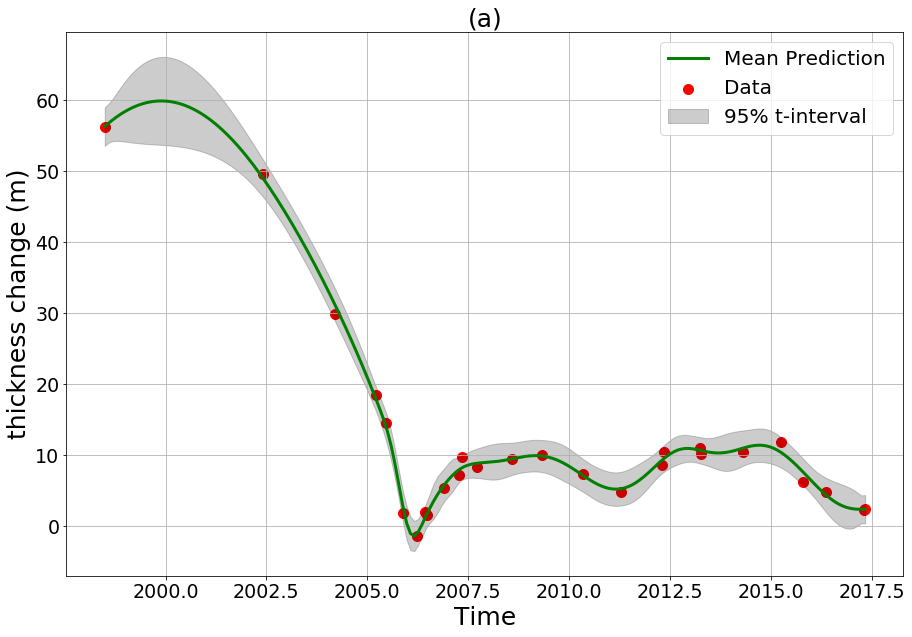

In [5]:
#figure(figsize=(20,8))
f1 = figure(figsize=(15,10))
ax = subplot2grid((1,1),(0,0))
####### Scatter plot for the smaller time series
p = 4;q=2
scatter(Data1[:,0],Data1[:,1],color = 'r',s = 100,label = 'Data')
[n,lamb,sigmasq] = full_search_nk(Data1,p,q)
c = n+p
U = Kno_pspline_opt(Data1,p,n)
B = Basis_Pspline(n,p,U,Data1[:,0])
P = Penalty_p(q,c)
theta = np.linalg.solve(B.T.dot(B) + lamb*P, B.T.dot(Data1[:,1].reshape(-1,1)))
### Getting mean of the prediction
num = 200
xpred = linspace(Data1[0,0],Data1[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
ypred1 = Bpred.dot(theta)
std_t1,std_n1 = Var_bounds(Data1,Bpred,B,theta,P,lamb)


ax.plot(xpred,ypred1,linewidth=3,color = 'g',label = 'Mean Prediction')
ax.set_title('(a)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred1.flatten()-std_t1,ypred1.flatten()+std_t1, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.legend(fontsize=20)
ax.grid(True)
show()

<a name="section_2"></a>
## <br />2. Using REML to Fit the ALPS Model[$\tiny\uparrow$](#top)

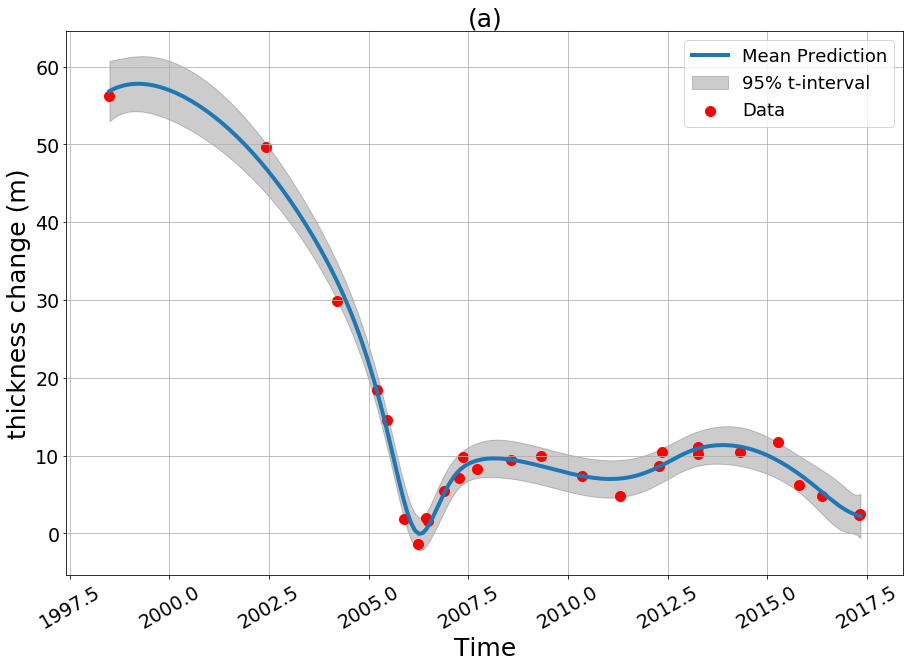

In [6]:
## Setting up the fiure and axis
fig = figure(figsize=(15,10))
ax = subplot2grid((1,1),(0,0))

## Chossing hyperparameters and initializations
p = 4;q=3
n = int(Data1.shape[0])
par = [0.1,0.1]

## Learning and Predicting
U = Kno_pspline_opt(Data1,p,n)
B = Basis_Pspline(n,p,U,Data1[:,0])
c = n+p
P = Penalty_p(q,c)
X,Z,C,sigma,D = XZsigma(B,P,q)
lamb,sig = max_reml(par,Data1,X,Z,sigma)

### Predicting
num = 200
xpred = linspace(Data1[0,0],Data1[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
Xpred,Zpred,Cpred,sigma,D = XZsigma(Bpred,P,q)
ypred3,std_t3,std_n3 = Inference(Data1,Cpred,C,lamb,sig,D,confidence=0.95)

## Plotting
ax.plot(xpred,ypred3,linewidth=4,label='Mean Prediction')
ax.set_title('(a)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred3.flatten()-std_t3,ypred3.flatten()+std_t3, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.grid(True)
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(30)
ax.scatter(Data1[:,0],Data1[:,1],label = 'Data',color = 'r',s=100)
ax.legend(fontsize=18)
ax.grid(True)
show()

<a name="section_3"></a>
## <br />3. Outlier Detection in Time Series using Two Stage Strategy[$\tiny\uparrow$](#top)

In [7]:
# Computing the Outliers and Clean data
dat,out = Outlier(Data4,thresh1=3,thresh2 = 1.2)

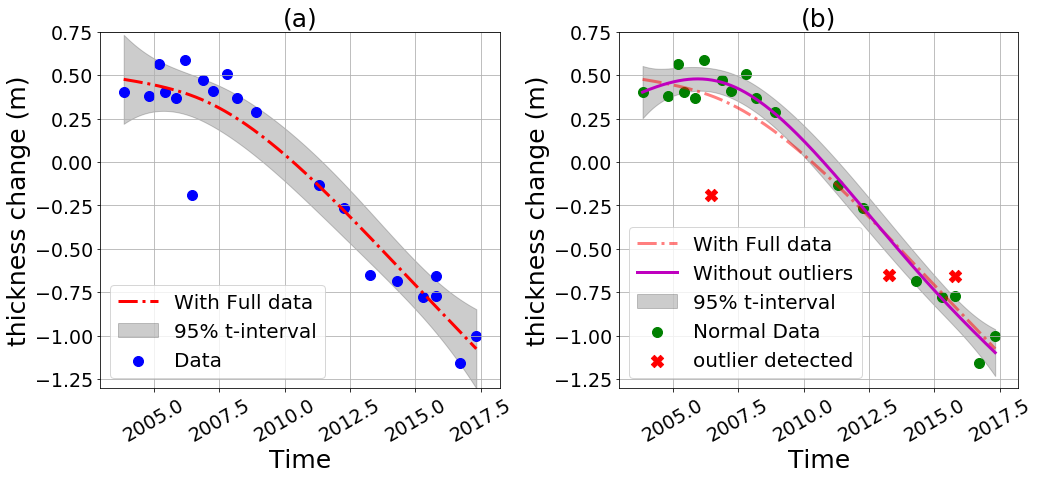

In [8]:
f1 = figure(figsize=(15,5))
ax = subplot2grid((1,2),(0,0))

p =4
q = 2
[n,lamb,sigmasq] = full_search_nk(Data4,p,q)
c = n+p
U = Kno_pspline_opt(Data4,p,n)
B = Basis_Pspline(n,p,U,Data4[:,0])
P = Penalty_p(q,c)
theta = np.linalg.solve(B.T.dot(B) + lamb*P, B.T.dot(Data4[:,1].reshape(-1,1)))
### Getting mean of the prediction
num = 300
xpred = linspace(Data4[0,0],Data4[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
ypred1 = Bpred.dot(theta)
std_t1,std_n1 = Var_bounds(Data4,Bpred,B,theta,P,lamb)


ax.plot(xpred,ypred1,linewidth=3,color = 'r',label = 'With Full data',linestyle = '-.')
#ax.set_title('Time Series 4',size = 25)
ax.set_title('(a)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred1.flatten()-std_t1,ypred1.flatten()+std_t1, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.scatter(Data4[:,0],Data4[:,1],label = 'Data',color = 'b',s=100)
ax.legend(fontsize=20,loc=3)
ax.set_ylim([-1.3,0.75])
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(30)
ax.grid(True)

###################################

ax = subplot2grid((1,2),(0,1))

Data = dat
[n,lamb,sigmasq] = full_search_nk(Data,p,q)
c = n+p
U = Kno_pspline_opt(Data,p,n)
B = Basis_Pspline(n,p,U,Data[:,0])
P = Penalty_p(q,c)
theta = np.linalg.solve(B.T.dot(B) + lamb*P, B.T.dot(Data[:,1].reshape(-1,1)))
### Getting mean of the prediction
num = 300
xpred = linspace(Data[0,0],Data[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
ypred2 = Bpred.dot(theta)
std_t2,std_n2 = Var_bounds(Data,Bpred,B,theta,P,lamb)

ax.plot(xpred,ypred1,linewidth=3,color = 'r',label = 'With Full data', linestyle = '-.',alpha = 0.5)
ax.plot(xpred,ypred2,linewidth=3,color = 'm', label = 'Without outliers')
ax.set_title('(b)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred2.flatten()-std_t2,ypred2.flatten()+std_t2, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.scatter(dat[:,0],dat[:,1],label = 'Normal Data',color = 'g',s = 100)
ax.scatter(out[:,0],out[:,1],label = 'outlier detected',color = 'r',s = 150, marker = 'X')
ax.legend(fontsize=20)
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(30)
ax.set_ylim([-1.3,0.75])
#subplots_adjust(left=0.19, bottom = 0, right = 0.94, top = 0.79,wspace = 0.3,hspace = 0.3)   # determines the padding on the graph
ax.grid(True)
subplots_adjust(left=0.09, bottom = 0, right = 0.94, top = 0.99,wspace = 0.3,hspace = 0.3)   # determines the padding on the graph
show()

<a name="section_4"></a>
## <br />4. Mixed Model Formulation for getting Local and Global Effects[$\tiny\uparrow$](#top)

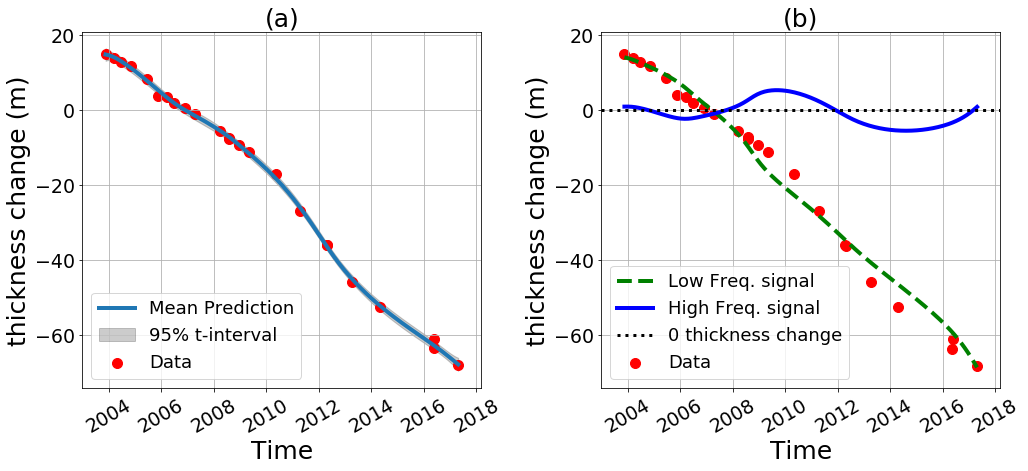

In [9]:
# Computing the Outliers and Clean data

fig = figure(figsize=(15,5))
ax = subplot2grid((1,2),(0,0))
ax.grid(True)

## Fitting REML model
p = 4;q=3
n = int(Data2.shape[0])
par = [0.1,0.1]
## Learning and Predicting

U = Kno_pspline_opt(Data2,p,n)
B = Basis_Pspline(n,p,U,Data2[:,0])
c = n+p
P = Penalty_p(q,c)
X,Z,C,sigma,D = XZsigma(B,P,q)
lamb,sig = max_reml(par,Data2,X,Z,sigma)
### Predicting
num = 200
xpred = linspace(Data2[0,0],Data2[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
Xpred,Zpred,Cpred,sigma,D = XZsigma(Bpred,P,q)
ypred3,std_t3,std_n3 = Inference(Data2,Cpred,C,lamb,sig,D,confidence=0.95)

ax.plot(xpred,ypred3,linewidth=4,label='Mean Prediction')
#ax.set_title('Time Series 3 (REML)',size = 20)
ax.set_title('(a)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred3.flatten()-std_t3,ypred3.flatten()+std_t3, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.grid(True)
ax.set_xticks(np.arange(2004, 2020, step=2))
for label in ax.xaxis.get_ticklabels():
    label.set_rotation(30)
ax.scatter(Data2[:,0],Data2[:,1],label = 'Data',color = 'r',s=100)
ax.legend(fontsize=18,loc = 3)



####### Plotting high and Low Frequency Components
ax = subplot2grid((1,2),(0,1))

f_low,f_high = Inference_effects(q,Data2,Cpred,C,lamb,D)
ax.plot(xpred,f_low,lw = 4,color = 'g', label = 'Low Freq. signal', linestyle = '--')
ax.plot(xpred,f_high,lw = 4, color = 'b', label = 'High Freq. signal')

#ax.set_title('Time Series 3 (REML): Signal Decomposition',size = 20)
ax.set_title('(b)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
#ax.fill_between(xpred.flatten(),ypred3.flatten()-std_t3,ypred3.flatten()+std_t3, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.grid(True)
ax.axhline(y=0, color='k', linestyle=':',label = '0 thickness change',lw=3)
ax.scatter(Data2[:,0],Data2[:,1],label = 'Data',color = 'r',s=100)
#subplots_adjust(left=0.19, bottom = 0, right = 0.94, top = 0.79,wspace = 0.3,hspace = 0.3)   # determines the padding on the graph
ax.legend(fontsize=18)
ax.set_xticks(np.arange(2004, 2020, step=2))

for label in ax.xaxis.get_ticklabels():
    label.set_rotation(30)
subplots_adjust(left=0.09, bottom = 0, right = 0.94, top = 0.99,wspace = 0.3,hspace = 0.3)   # determines the padding on the graph

show()

<a name="section_5"></a>
## <br />5. Computation of First Derivative with CIs[$\tiny\uparrow$](#top)

Here we show the capability of ALPS to compute the first order derivative. Actually its even possible to compute derivatives of higher order by changing the order in the main code.

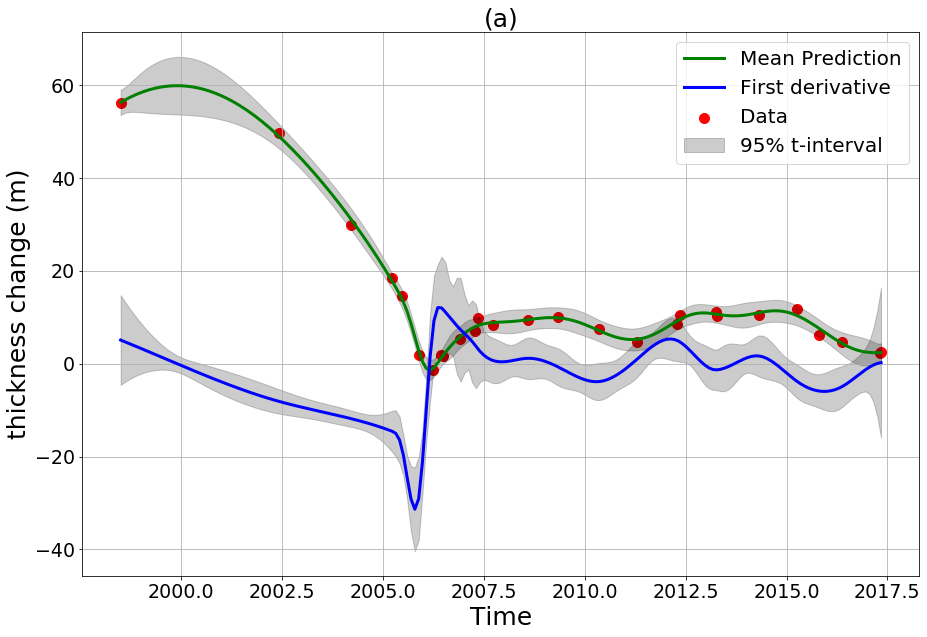

In [10]:
# Fitting and plotting
f1 = figure(figsize=(15,10))
ax = subplot2grid((1,1),(0,0))

p = 4;q=2
[n,lamb,sigmasq] = full_search_nk(Data1,p,q)
c = n+p
U = Kno_pspline_opt(Data1,p,n)
B = Basis_Pspline(n,p,U,Data1[:,0])
P = Penalty_p(q,c)
theta = np.linalg.solve(B.T.dot(B) + lamb*P, B.T.dot(Data1[:,1].reshape(-1,1)))
### Getting mean of the prediction
num = 200
xpred = linspace(Data1[0,0],Data1[-1,0],num)
Bpred = Basis_Pspline(n,p,U,xpred)
ypred1 = Bpred.dot(theta)
std_t1,std_n1 = Var_bounds(Data1,Bpred,B,theta,P,lamb)
## Getting the derivative
Bpred_dert = Basis_derv_Pspline(n,p,U,xpred)
ypred_derth = Bpred_dert.dot(theta)
std_th_derv,std_nh_derv = Var_bounds(Data1,Bpred_dert,B,theta,P,lamb)


## Plotting
ax.scatter(Data1[:,0],Data1[:,1],color = 'r',s = 100,label = 'Data')
ax.plot(xpred,ypred1,linewidth=3,color = 'g',label = 'Mean Prediction')
ax.plot(xpred,ypred_derth,linewidth=3,color = 'b',label = 'First derivative')
ax.set_title('(a)',size = 25)
ax.tick_params(axis='x', labelsize=19)
ax.tick_params(axis='y', labelsize=19)
ax.set_xlabel('Time',size=25)
ax.set_ylabel('thickness change (m)',size = 25)
ax.fill_between(xpred.flatten(),ypred1.flatten()-std_t1,ypred1.flatten()+std_t1, alpha = 0.2,color = 'k',label = '95% t-interval')
ax.fill_between(xpred.flatten(),ypred_derth.flatten()-std_th_derv,ypred_derth.flatten()+std_th_derv, alpha = 0.2,color = 'k')


ax.legend(fontsize=20)
ax.grid(True)
show()


In [11]:
# Prevent In[] and Out[] from displaying on left
HTML('''
<style>.prompt{width: 0px; min-width: 0px; visibility: collapse}</style>
''')

In [12]:
# Scroll to top when the notebook is loaded
HTML('''
<script>
    function scroll_to_top() {
        Jupyter.notebook.scroll_to_top();
    } 
    $( window ).on( "load", scroll_to_top() );
</script>
''')